True
100 100
[0.00264525 0.00189327 0.00149453 0.0012526  0.00109454 0.00098722
 0.0009136  0.00086426 0.00083379 0.00081922 0.00081922 0.00083379
 0.00086426 0.0009136  0.00098722 0.00109454 0.0012526  0.00149453
 0.00189327 0.00264525]
True
100 100
[0.00793576 0.00567982 0.00448358 0.0037578  0.00328363 0.00296167
 0.00274081 0.00259277 0.00250136 0.00245766 0.00245766 0.00250136
 0.00259277 0.00274081 0.00296167 0.00328363 0.0037578  0.00448358
 0.00567982 0.00793576]
True
100 100
[0.01322627 0.00946636 0.00747263 0.006263   0.00547272 0.00493611
 0.00456802 0.00432128 0.00416894 0.0040961  0.0040961  0.00416894
 0.00432128 0.00456802 0.00493611 0.00547272 0.006263   0.00747263
 0.00946636 0.01322627]
True
100 100
[0.01851678 0.01325291 0.01046169 0.0087682  0.00766181 0.00691056
 0.00639523 0.0060498  0.00583651 0.00573454 0.00573454 0.00583651
 0.0060498  0.00639523 0.00691056 0.00766181 0.0087682  0.01046169
 0.01325291 0.01851678]
True
100 100
[0.02380729 0.01703945 0.01345074 0

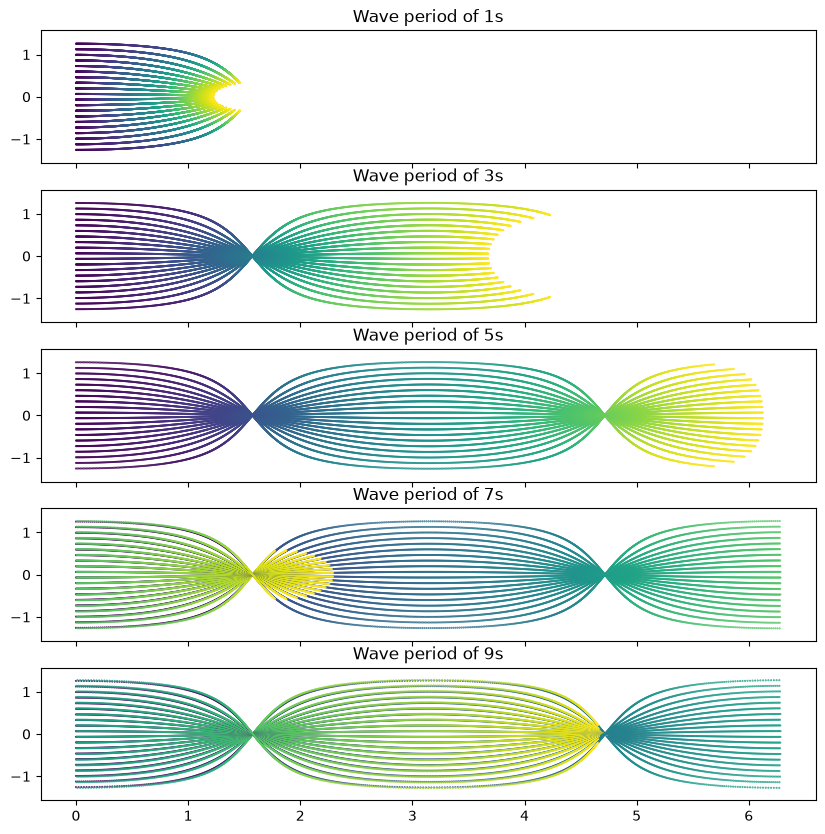

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ocean_wave_tracing.ocean_wave_tracing import Wave_tracing

# Defining some properties of the medium
nx = 100; ny = 100 # number of grid points in x- and y-direction
x = np.linspace(0,np.pi/300,nx) # size x-domain [m] 
y = np.linspace(-np.pi*0.4,np.pi*0.4,ny) # size y-domain [m]
T = 10000000#0000 # simulation time [s]
#U=np.ones((nx,ny))*50
#U[nx//2:,:]=1

fig, ax = plt.subplots(5,1, figsize=(10,10), sharex=True)

for i in range(0,5):        
    # Define a wave tracing object
    wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*1000,
                        nx=nx, ny=ny, nt=1500,T=T,
                        dx=x[1]-x[0],dy=y[1]-y[0],
                        nb_wave_rays=20,
                        domain_X0=x[0], domain_XN=x[-1],
                        domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                        )

    # Set initial conditions
    wt.set_initial_condition(wave_period=2*i+1,
                                theta0=0)
    # Solve
    wt.solve()

    print(len(x), len(y))

    # Plot
    #pc=ax[i].pcolormesh(wt.x,wt.y,wt.U.isel(time=0),shading='auto');
    ax[i].set_title(f"Wave period of {2*i+1}s")
    #ax[i].set_xlim(x[0], 0.020)
    ax[i].set_ylim(-np.pi/2, np.pi/2)

    for ray_id in range(wt.nb_wave_rays):
        colors = np.arange(0, len(wt.ray_x[ray_id,:]), 1)
        ax[i].scatter(wt.ray_x[ray_id,:], wt.ray_y[ray_id,:], c=colors, cmap="viridis", s=0.2)

    print(wt.ray_x[:,1])



plt.show()

Text(0.5, 0.98, 'Evolution of ray parameters over a period of 2800 hours, eastern propagation')

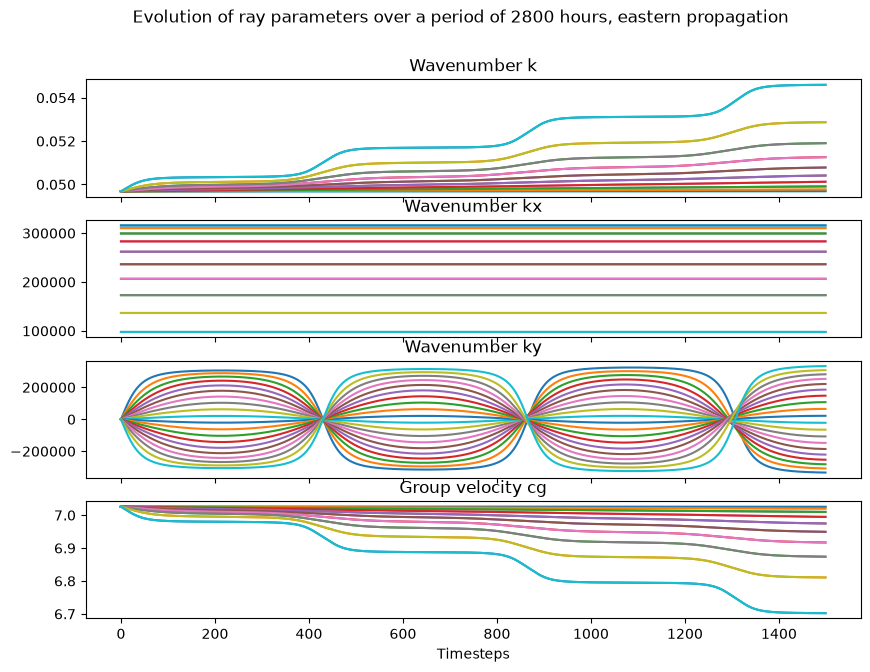

In [2]:
fig, ax = plt.subplots(4,1, figsize=(10,7), sharex=True)
for ray in wt.ray_k:
    ax[0].plot(ray)
    #ax[0].set_xlim(0,10)
for ray in wt.ray_kx:
    ax[1].plot(ray)
for ray in wt.ray_ky:
    ax[2].plot(ray)
for ray in wt.ray_cg:
    ax[3].plot(ray)
ax[0].set_title("Wavenumber k")
ax[1].set_title("Wavenumber kx")
ax[2].set_title("Wavenumber ky")
ax[3].set_title("Group velocity cg")
ax[3].set_xlabel("Timesteps")
fig.suptitle("Evolution of ray parameters over a period of 2800 hours, eastern propagation")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_greatcircle(theta,phi,lambd):
    xi = np.linspace(0,2*np.pi,10000)[:-2]
    x = (np.cos(xi)*np.cos(phi)-np.sin(xi)*np.sin(theta)*np.sin(phi))*np.cos(lambd) - np.sin(xi)*np.cos(theta)*np.sin(lambd)
    y = (np.cos(xi)*np.cos(phi)-np.sin(xi)*np.sin(theta)*np.sin(phi))*np.sin(lambd) + np.sin(xi)*np.cos(theta)*np.cos(lambd)
    z = np.cos(xi)*np.sin(phi) + np.sin(xi)*np.sin(theta)*np.sin(phi)
    lat = np.arcsin(z)
    lon = np.atan2(y,x)% (2 * np.pi)
    return lat, lon

Text(0.5, 0, 'longitude (rad)')

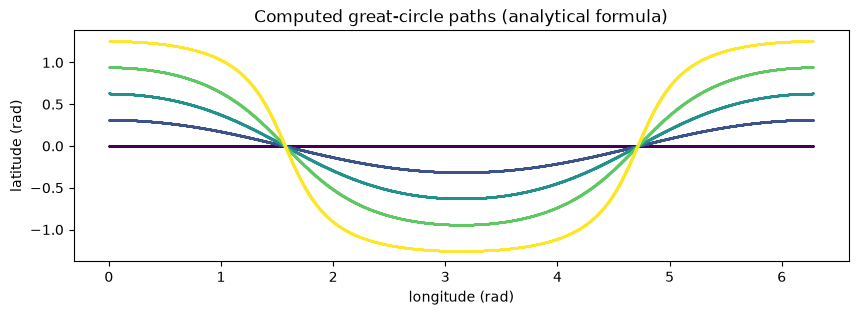

In [4]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10,3))

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,5))

for phi, c in zip(np.linspace(0, np.pi*0.4, 5),colors):
    lat, lon = generate_greatcircle(0, phi, 0)
    ax.scatter(lon, lat, s=0.1, color=c)

ax.set_title("Computed great-circle paths (analytical formula)")
ax.set_ylabel("latitude (rad)")
ax.set_xlabel("longitude (rad)")



True


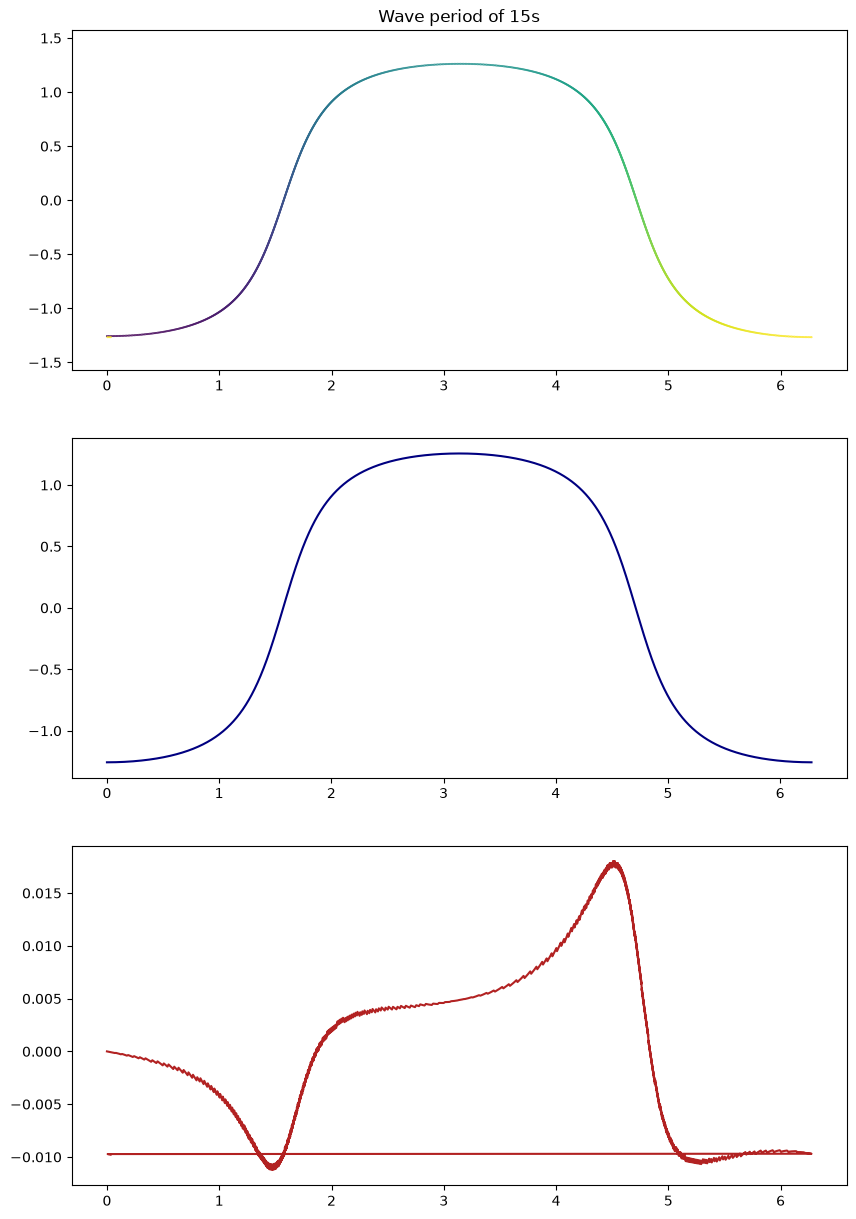

In [5]:
# method for evaluating the differences between the analytical great-circle path and the OWT result
def test_difference_analytical_owt(lat_ana, lon_ana, lat_owt, lon_owt):
    def differences(i, lon):
        best_fit_index = np.argmin([np.abs(lon-l) for l in lon_ana])
        lon_out = lon_ana[best_fit_index]
        delta_out = lat_owt[i]-lat_ana[best_fit_index]
        return [delta_out, lon_out]
    return np.array([differences(i, lon) for i, lon in enumerate(lon_owt)]).T

# test for one case 
# initialize the OWT data
nx = 100; ny = 100 # number of grid points in x- and y-direction
x = np.linspace(0,np.pi/300,nx) # size x-domain [m] 
y = np.linspace(-np.pi*0.4,np.pi*0.4,ny) # size y-domain [m]
T = 3450000
wt = Wave_tracing(U=np.zeros((ny,nx)),V=np.zeros((ny,nx)), d=np.ones((ny,nx))*1000,
                    nx=nx, ny=ny, nt=1500,T=T,
                    dx=x[1]-x[0],dy=y[1]-y[0],
                    nb_wave_rays=1,
                    domain_X0=x[0], domain_XN=x[-1],
                    domain_Y0=y[0], domain_YN=y[-1], is_spherical=True
                    )

# Set initial conditions
wt.set_initial_condition(wave_period=15,
                            theta0=0)
# Solve
wt.solve()

fig, ax = plt.subplots(3,1, figsize=(10,15))

ax[0].set_title(f"Wave period of {15}s")
#ax[i].set_xlim(x[0], 0.020)
ax[0].set_ylim(-np.pi/2, np.pi/2)

ray_id = 0
colors = np.arange(0, len(wt.ray_x[ray_id,:]), 1)
ax[0].scatter(wt.ray_x[ray_id,:], wt.ray_y[ray_id,:], c=colors, cmap="viridis", s=0.2)

#initialize the analytical data
lat, lon = generate_greatcircle(0, wt.ray_y[ray_id,0], 0)

#compute differences
diffs, lons = test_difference_analytical_owt(lat, lon, wt.ray_y[ray_id,:], wt.ray_x[ray_id,:])

ax[1].plot(lon, lat, color="navy")
ax[2].plot(lons, diffs, color="firebrick")

